# Model A Baseline

This notebook trains the binary classifier with transfer learning and creates the shared 70/30 split used by the other notebooks.

- Input size: 128 x 128
- Split: 70 percent training and 30 percent testing
- Labels: NORMAL = 0 and ABNORMAL (DME and DRUSEN) = 1 

In [1]:
!nvidia-smi

Sat Apr 18 04:13:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             60W /  400W |   10055MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

In [3]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
label_map = {"NORMAL": 0, "DME": 1, "DRUSEN": 1}

# Locate the project root directory.
def find_root():
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "notebooks").exists() and (root / "requirements.txt").exists():
            return root
    for root in [Path("/content/OCT-SRGAN"), Path("/content/drive/MyDrive/OCT-SRGAN")]:
        if root.exists():
            return root
    return cwd

# Locate the dataset directory.
def find_data(root_dir):
    data_dir = root_dir / "data"
    if (data_dir / "train").exists() and (data_dir / "test").exists():
        return data_dir
    for data_dir in [
        Path("/content/data"),
        Path("/content/drive/MyDrive/data"),
    ]:
        if (data_dir / "train").exists() and (data_dir / "test").exists():
            return data_dir
    raise FileNotFoundError("Dataset not found.")

root_dir = find_root()
data_dir = find_data(root_dir)

train_dir = data_dir / "train"
test_dir = data_dir / "test"
split_dir = root_dir / "artifacts" / "splits"
ckpt_dir = root_dir / "checkpoints" / "model_a"
for out_dir in [split_dir, ckpt_dir]:
    out_dir.mkdir(parents=True, exist_ok=True)

print("root_dir:", root_dir)
print("data_dir:", data_dir)
print("train_dir exists:", train_dir.exists())
print("test_dir exists:", test_dir.exists())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Torch version:", torch.__version__)
print("CUDA ready:", torch.cuda.is_available())

root_dir: /content/OCT-SRGAN
data_dir: /content/OCT-SRGAN/data
train_dir exists: True
test_dir exists: True
Torch version: 2.10.0+cu128
CUDA ready: True


In [5]:
img_size = 128
batch_size = 32
epochs = 10
save_gap = 5
learn_rate = 1e-3
worker_n = 2

In [6]:
# Collect image paths and binary labels.
def collect_rows(data_dir):
    ext_set = {".tif"}
    row_list = []
    if not data_dir.exists():
        return row_list
    for class_dir in sorted(data_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        class_name = class_dir.name.upper()
        if class_name not in label_map:
            continue
        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in ext_set:
                row_list.append(
                    {
                        "path": str(img_path),
                        "org_class": class_name,
                        "bin_label": label_map[class_name],
                    }
                )
    return row_list

row_list = collect_rows(train_dir) + collect_rows(test_dir)
data_df = pd.DataFrame(row_list, columns=["path", "org_class", "bin_label"])

print("Total images:", len(data_df))
print("Class counts:")
print(data_df["org_class"].value_counts())

if len(data_df) == 0:
    raise ValueError("No images found")

if data_df["bin_label"].nunique() < 2:
    raise ValueError("Need at least two classes before stratified split.")

train_df, test_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=seed,
    stratify=data_df["bin_label"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(split_dir / "train_split.csv", index=False)
test_df.to_csv(split_dir / "test_split.csv", index=False)

print("Train:", len(train_df), "Test:", len(test_df))

Total images: 3231
Class counts:
org_class
NORMAL    1407
DME       1101
DRUSEN     723
Name: count, dtype: int64
Train: 2261 Test: 970


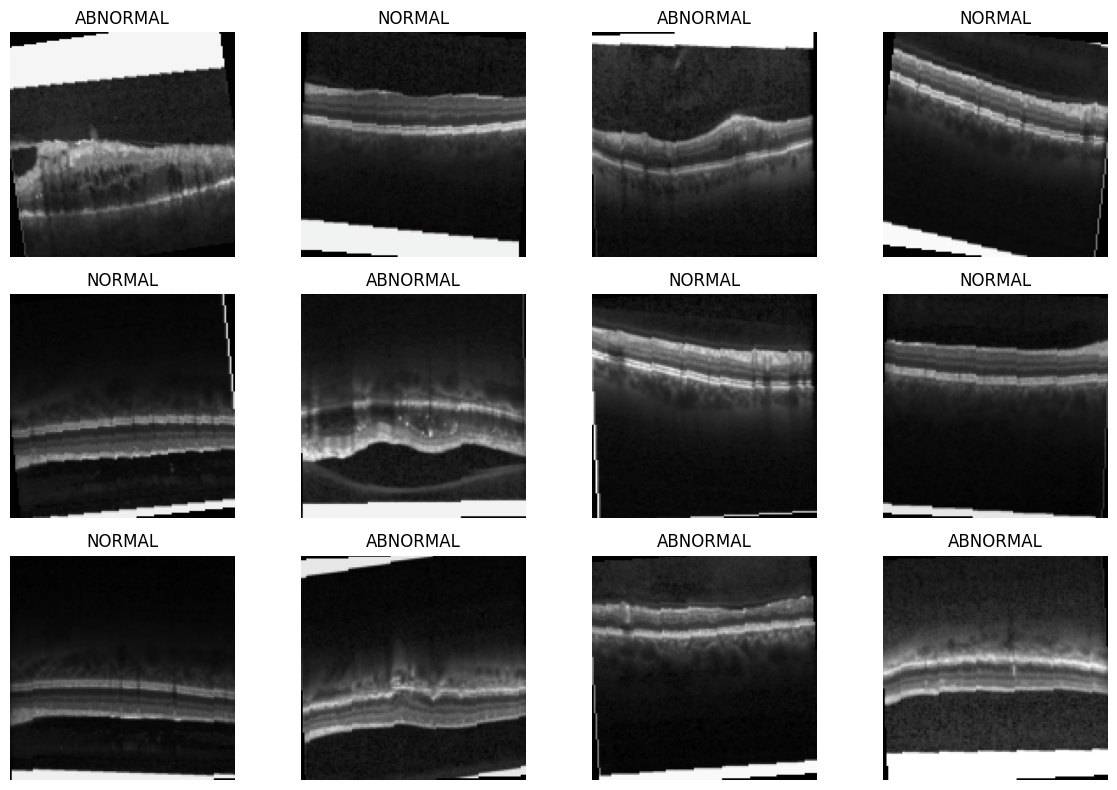

In [7]:
train_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.10, contrast=0.10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Dataset wrapper for OCT image classification.
class OCTSet(Dataset):
    # Initialize class state.
    def __init__(self, data_df, img_tf):
        self.data_df = data_df.reset_index(drop=True)
        self.img_tf = img_tf

    # Return the dataset size.
    def __len__(self):
        return len(self.data_df)

    # Return a single sample.
    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img_x = self.img_tf(img)
        img_y = torch.tensor(float(row["bin_label"]), dtype=torch.float32)
        return img_x, img_y

train_set = OCTSet(train_df, train_tf)
test_set = OCTSet(test_df, eval_tf)

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    num_workers=worker_n,
    pin_memory=True,
)
test_loader = DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=worker_n,
    pin_memory=True,
)

# Below is to help visualize some of the training images after transformations, denormalizing them back to [0, 1] range for display. 
def denorm_img(img_x):
    img_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_x.cpu() * img_std) + img_mean

img_x, img_y = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for idx in range(min(12, img_x.size(0))):
    plt.subplot(3, 4, idx + 1)
    plt.imshow(denorm_img(img_x[idx]).permute(1, 2, 0).clamp(0, 1).numpy())
    plt.title("ABNORMAL" if int(img_y[idx].item()) == 1 else "NORMAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

Epoch 001/10 | Train AUC 0.7951
Epoch 002/10 | Train AUC 0.9623
Epoch 003/10 | Train AUC 0.9874
Epoch 004/10 | Train AUC 0.9923
Epoch 005/10 | Train AUC 0.9964
Epoch 006/10 | Train AUC 0.9968
Epoch 007/10 | Train AUC 0.9976
Epoch 008/10 | Train AUC 0.9979
Epoch 009/10 | Train AUC 0.9966
Epoch 010/10 | Train AUC 0.9966


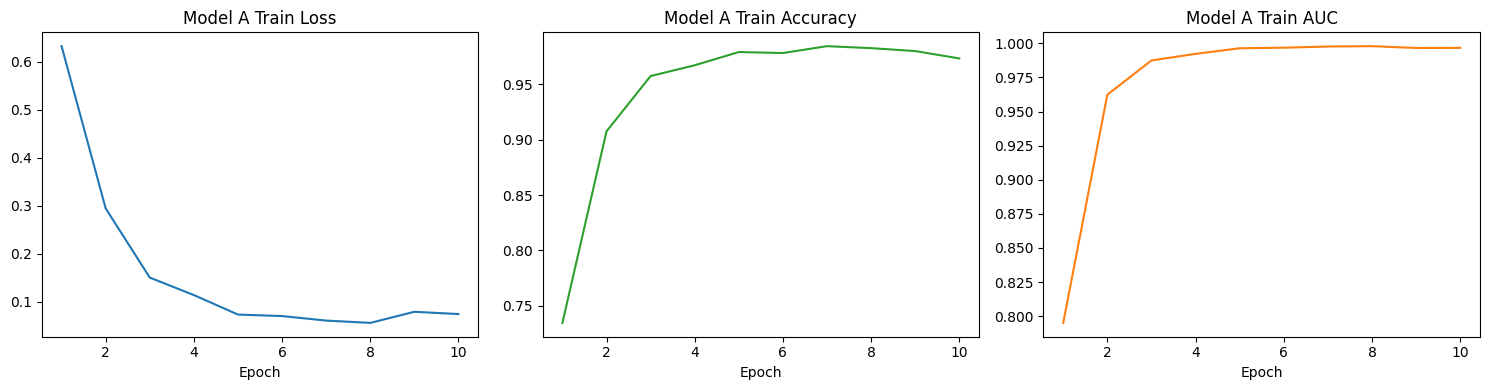

,epoch,train_loss,train_acc,train_auc
5,6,0.070198,0.978328,0.996790
6,7,0.060779,0.984520,0.997637
7,8,0.055988,0.982751,0.997906
8,9,0.079117,0.980097,0.996576
9,10,0.074359,0.973463,0.996648


In [8]:
net = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
for param in net.features[:-8].parameters():
    param.requires_grad = False
net.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(1024, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
)
net = net.to(device)
loss_fn = nn.BCEWithLogitsLoss()
opt = optim.Adam(filter(lambda param: param.requires_grad, net.parameters()), lr=learn_rate)

# Run one training or evaluation pass.
def run_pass(data_loader, train_on):
    net.train(train_on)
    loss_sum = 0.0
    prob_all, lab_all = [], []
    for img_x, img_y in data_loader:
        img_x = img_x.to(device, non_blocking=True)
        img_y = img_y.to(device, non_blocking=True).view(-1, 1)
        with torch.set_grad_enabled(train_on):
            logits = net(img_x)
            loss = loss_fn(logits, img_y)
            if train_on:
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()
        loss_sum += loss.item() * img_x.size(0)
        prob_all.append(torch.sigmoid(logits).detach().cpu().numpy().ravel())
        lab_all.append(img_y.detach().cpu().numpy().ravel())
    prob_all = np.concatenate(prob_all)
    lab_all = np.concatenate(lab_all)
    pred_all = (prob_all >= 0.5).astype(int)
    loss_avg = loss_sum / len(data_loader.dataset)
    acc_val = accuracy_score(lab_all, pred_all)
    auc_val = roc_auc_score(lab_all, prob_all)
    return loss_avg, acc_val, auc_val

log_rows = []
for epoch in range(1, epochs + 1):
    loss_val, acc_val, auc_val = run_pass(train_loader, True)
    log_rows.append({"epoch": epoch, "train_loss": loss_val, "train_acc": acc_val, "train_auc": auc_val})
    if epoch % save_gap == 0:
        torch.save(net.state_dict(), ckpt_dir / f"model_a_epoch_{epoch:03d}.pth")
    print(f"Epoch {epoch:03d}/{epochs} | Train AUC {auc_val:.4f}")

torch.save(net.state_dict(), ckpt_dir / "model_a_final.pth")
log_df = pd.DataFrame(log_rows)

fig, axis = plt.subplots(1, 3, figsize=(15, 4))
axis[0].plot(log_df["epoch"], log_df["train_loss"], color="tab:blue")
axis[0].set_title("Model A Train Loss")
axis[0].set_xlabel("Epoch")
axis[1].plot(log_df["epoch"], log_df["train_acc"], color="tab:green")
axis[1].set_title("Model A Train Accuracy")
axis[1].set_xlabel("Epoch")
axis[2].plot(log_df["epoch"], log_df["train_auc"], color="tab:orange")
axis[2].set_title("Model A Train AUC")
axis[2].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

log_df.tail()

In [9]:
net.load_state_dict(torch.load(ckpt_dir / "model_a_final.pth", map_location=device))
net.eval()

prob_all, lab_all = [], []
with torch.no_grad():
    for img_x, img_y in test_loader:
        img_x = img_x.to(device, non_blocking=True)
        logits = net(img_x)
        prob_all.append(torch.sigmoid(logits).cpu().numpy().ravel())
        lab_all.append(img_y.numpy().ravel())

y_prob = np.concatenate(prob_all)
y_true = np.concatenate(lab_all).astype(int)
y_pred = (y_prob >= 0.5).astype(int)

score_a = {
    "accuracy": float(accuracy_score(y_true, y_pred)),
    "f1": float(f1_score(y_true, y_pred)),
    "auc": float(roc_auc_score(y_true, y_prob)),
}
print(score_a)

score_df = pd.DataFrame([score_a], index=["Model A"])
score_df

pred_df = test_df.copy()
pred_df["prob_abnormal"] = y_prob
pred_df["pred_label"] = y_pred
pred_df.head()

{'accuracy': 0.9814432989690721, 'f1': 0.9833024118738405, 'auc': 0.9995891998477877}


,path,org_class,bin_label,prob_abnormal,pred_label
0,/content/OCT-SRGAN/data/test/DME/DME15_034.tif,DME,1,0.918951,1
1,/content/OCT-SRGAN/data/train/DRUSEN/AMD7_041.tif,DRUSEN,1,0.999955,1
2,/content/OCT-SRGAN/data/test/DRUSEN/AMD13_031.tif,DRUSEN,1,1.000000,1
3,/content/OCT-SRGAN/data/train/DRUSEN/AMD10_027...,DRUSEN,1,0.999980,1
4,/content/OCT-SRGAN/data/train/DME/DME3_093.tif,DME,1,0.999873,1
